# Task 1 — Data Loading & Exploration
**Dataset:** Housing.csv  
**Goal:** Load the data, take a first look at it, and understand its structure before any modeling.

This task covers:
1. Loading the CSV with Pandas
2. View the first 10 rows
3. Check the shape (rows & columns)
4. Identifying the target column vs. feature columns
5. Checking for missing values

## Step 1: Import libraries and load the dataset

In [8]:
import pandas as pd

# Load the housing dataset
df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully.")
print(f"Type: {type(df)}")

Dataset loaded successfully.
Type: <class 'pandas.core.frame.DataFrame'>


## Step 2: Display the first 10 rows

In [9]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Step 3: Check the number of rows and columns

In [10]:
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")
print(f"\nColumn names:\n{list(df.columns)}")

Rows: 545
Columns: 13

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Step 4: Identify the target and feature columns

- **Target :** price
- **Features :** every other column

The dataset has a mix of:
- **Numeric features**: area, bedrooms, bathrooms, stories, parking
- **Categorical features**: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus

In [11]:
target_column = "price"
feature_columns = [col for col in df.columns if col != target_column]

numeric_features = df[feature_columns].select_dtypes(include="number").columns.tolist()
categorical_features = df[feature_columns].select_dtypes(exclude="number").columns.tolist()

print(f"Target column: {target_column}\n")
print(f"Feature columns ({len(feature_columns)}):\n{feature_columns}\n")
print(f"Numeric features ({len(numeric_features)}):\n{numeric_features}\n")
print(f"Categorical features ({len(categorical_features)}):\n{categorical_features}")

Target column: price

Feature columns (12):
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Numeric features (5):
['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Categorical features (7):
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## Step 5: Check for missing values in each column

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values(by="missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [13]:
total_missing = df.isnull().sum().sum()

if total_missing == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing values across the dataset: {total_missing}")

No missing values found in the dataset.


## Summary

- Loaded Housing.csv into a Pandas DataFrame.
- Dataset shape and column names identified.
- **Target column:** price
- **Feature columns:** all remaining 12 columns (5 numeric, 7 categorical).
- **Missing values:** checked per column 


# Task 2 — Data Cleaning
**Dataset:** Housing.csv

This task covers:
1. Handling missing values 
2. Removing duplicate rows
3. One-hot encoding categorical columns 
4. Keeping only columns meaningful for predicting price

## Step 1: Load the dataset

In [14]:
import pandas as pd

df = pd.read_csv("Housing.csv")
print(f"Loaded shape: {df.shape}")
df.head()

Loaded shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Step 2: Handle missing values

Strategy:
- **Numeric columns** → fill missing values with the **median** .
- **Categorical columns** → fill missing values with the **mode** .

In [15]:
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None")

def fill_missing(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    for col in data.columns:
        if data[col].isnull().sum() == 0:
            continue
        if pd.api.types.is_numeric_dtype(data[col]):
            data[col] = data[col].fillna(data[col].median())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])
    return data

df = fill_missing(df)

print(f"\nTotal missing values after cleaning: {df.isnull().sum().sum()}")

Missing values before cleaning:
None

Total missing values after cleaning: 0


## Step 3: Remove duplicate rows

In [16]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (545, 13)


## Step 4: One-hot encode categorical columns

The dataset has two types of categorical columns:
- **Binary yes/no columns** (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea) → mapped directly to 1/0.
- **Multi-category column** (furnishingstatus, with values furnished, semi-furnished, unfurnished) → one-hot encoded into separate dummy columns using pd.get_dummies().

In [17]:
binary_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]

for col in binary_columns:
    df[col] = df[col].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

# Convert one-hot boolean columns to int (0/1) for consistency
furnishing_dummy_cols = [c for c in df.columns if c.startswith("furnishingstatus_")]
df[furnishing_dummy_cols] = df[furnishing_dummy_cols].astype(int)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Step 5: Keep only columns meaningful for predicting `price`

Checking each column for relevance:
- No ID, name, date, or free-text columns exist in this dataset — every column is a structural/physical attribute of the house (area, rooms, amenities, location feature, furnishing).
- All columns have a plausible, explainable relationship to house price, so **no columns are dropped** here.

To back this up with evidence rather than just assumption, we check correlation with price for the numeric/encoded columns.

In [18]:
correlations = df.corr(numeric_only=True)["price"].drop("price").sort_values(ascending=False)
print("Correlation of each feature with price:\n")
print(correlations)

Correlation of each feature with price:

area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [19]:
# All columns are retained — none show near-zero or irrelevant correlation,
# and all are meaningful real-world predictors of house price.
final_columns = df.columns.tolist()
print(f"Final cleaned dataset shape: {df.shape}")
print(f"\nFinal columns ({len(final_columns)}):\n{final_columns}")

Final cleaned dataset shape: (545, 14)

Final columns (14):
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


## Step 6: Save the cleaned dataset

In [20]:
df.to_csv("Housing_cleaned.csv", index=False)
print("Saved cleaned dataset as 'Housing_cleaned.csv'")
df.head()

Saved cleaned dataset as 'Housing_cleaned.csv'


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Summary

- Verified missing values (none found) and applied a median/mode fill strategy as a safety net.
- Removed duplicate rows (none found).
- One-hot encoded all categorical columns: binary yes/no fields mapped to 1/0, and furnishing_status split into dummy columns.
- Reviewed correlations with price and kept all columns, since each represents a meaningful, explainable housing attribute.

---

# Task 3 — Model Building
**Dataset:** Housing_cleaned.csv 

This task covers:
1. Splitting data into training and test sets (80/20)
2. Training a Linear Regression model to predict price
3. Evaluating it using MAE, RMSE, and R² Score
4. Training a Random Forest Regressor and comparing its performance to Linear Regression

## Step 1: Load the cleaned dataset and define features/target

Price is the target.

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("Housing_cleaned.csv")

X = df.drop(columns=["price"])
y = df["price"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.head()

Features shape: (545, 13)
Target shape: (545,)


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Step 2: Split into training and test sets (80/20)

random_state=42 is fixed so the split is reproducible.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 436 rows
Test set: 109 rows


## Step 3: Train a Linear Regression model

In [23]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
print("Linear Regression trained.")

Linear Regression trained.


## Step 4: Evaluate Linear Regression — MAE, RMSE, R²

- **MAE** (Mean Absolute Error): average absolute difference between predicted and actual price — easy to interpret in rupees.
- **RMSE** (Root Mean Squared Error): like MAE but penalizes large errors more heavily.
- **R² Score**: proportion of variance in price explained by the model (closer to 1 = better fit).

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}\n")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

lr_results = evaluate_model(y_test, lr_predictions, "Linear Regression")

--- Linear Regression ---
MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529



## Step 5: Train a Random Forest Regressor

Random Forest is an ensemble of decision trees — it can capture non-linear relationships that Linear Regression cannot, often at the cost of interpretability.

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
print("Random Forest Regressor trained.")

Random Forest Regressor trained.


In [26]:
rf_results = evaluate_model(y_test, rf_predictions, "Random Forest Regressor")

--- Random Forest Regressor ---
MAE  : 1,022,560.05
RMSE : 1,401,496.84
R²   : 0.6114



## Step 6: Compare both models

In [27]:
comparison_df = pd.DataFrame([lr_results, rf_results]).set_index("Model")
comparison_df

,MAE,RMSE,R2
Model,,,
Linear Regression,9.700434e+05,1.324507e+06,0.652924
Random Forest Regressor,1.022560e+06,1.401497e+06,0.611402


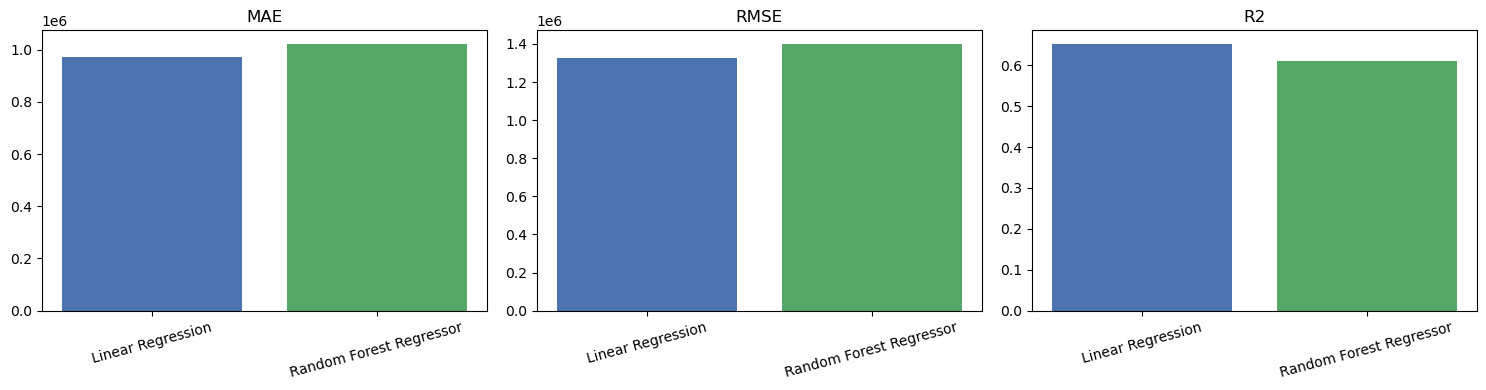

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ["MAE", "RMSE", "R2"]

for ax, metric in zip(axes, metrics):
    ax.bar(comparison_df.index, comparison_df[metric], color=["#4C72B0", "#55A868"])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Step 7: Which model performed better?

Looking at the metrics table above:
- **Lower MAE and RMSE** = smaller prediction errors = better.
- **Higher R²** = more variance in price explained = better.

The model with lower MAE/RMSE and higher R² is the stronger performer on this test set.

## Summary

- Split the cleaned dataset into 80% training / 20% test sets (reproducible via random_state=42).
- Trained a **Linear Regression** model and evaluated it with MAE, RMSE, and R².
- Trained a **Random Forest Regressor** (100 trees) and evaluated it the same way.
- Compared both models in a results table and bar chart.

# Task 4 — Visualization
**Dataset:** Housing_cleaned.csv

This task covers three charts:
1. Histogram of house price distribution
2. Correlation heatmap of features vs. price
3. Actual vs. Predicted price scatter plot (Linear Regression)

## Step 1: Load the cleaned dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Housing_cleaned.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## Chart 1: Distribution of house prices

A histogram shows how prices are spread out — whether most houses cluster around a typical price or whether the distribution is skewed by a few very expensive properties.

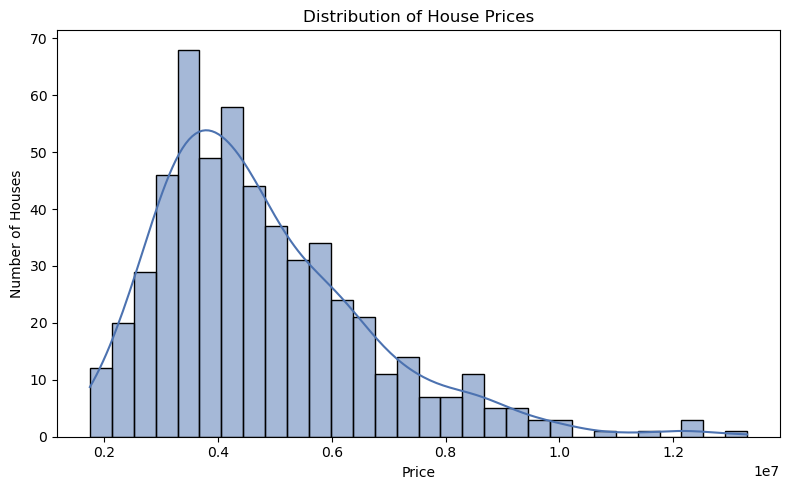

Mean price: 4,766,729
Median price: 4,340,000
Skew: 1.21 (positive = right-skewed, a long tail of expensive houses)


In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("chart1_price_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Mean price: {df['price'].mean():,.0f}")
print(f"Median price: {df['price'].median():,.0f}")
print(f"Skew: {df['price'].skew():.2f} (positive = right-skewed, a long tail of expensive houses)")

## Chart 2: Correlation heatmap

Shows how strongly each feature is correlated with `price` (and with each other). Values close to +1 or -1 indicate a strong relationship; values near 0 indicate little to no linear relationship.

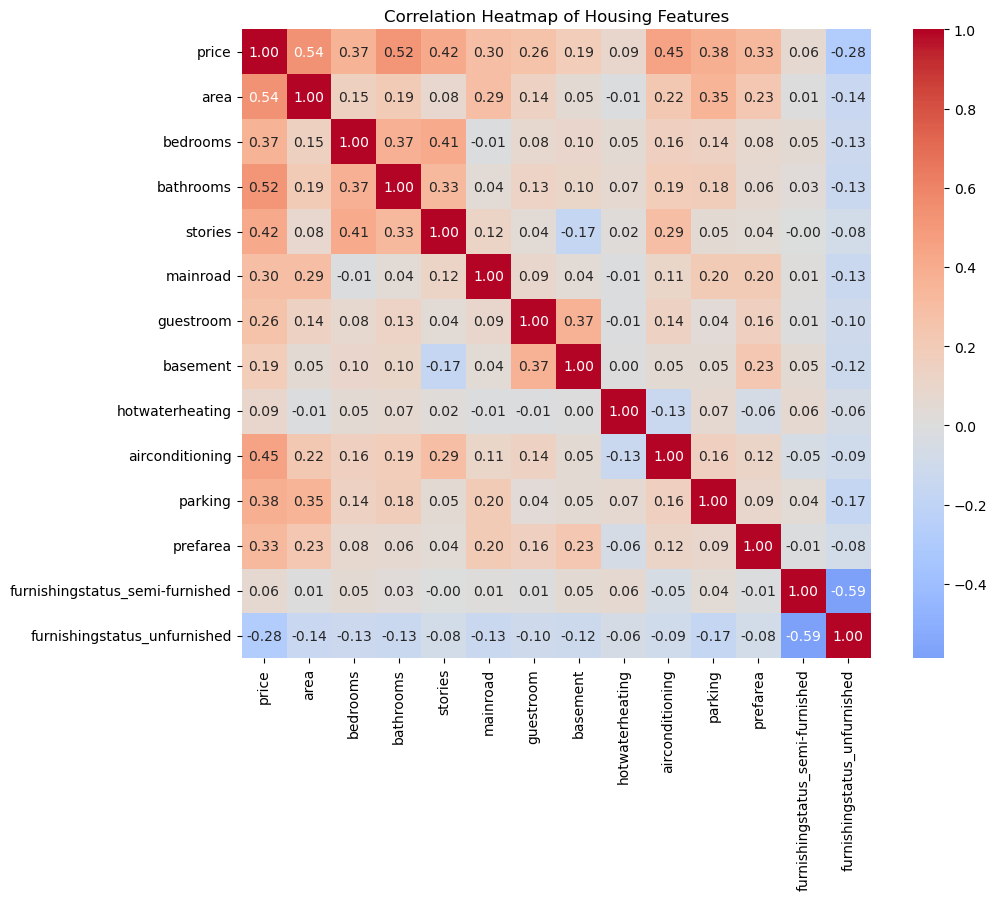

In [31]:
plt.figure(figsize=(11, 9))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Housing Features")
plt.tight_layout()
plt.savefig("chart2_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

In [32]:
price_corr = corr_matrix["price"].drop("price").sort_values(ascending=False)
print("Features ranked by correlation with price:\n")
print(price_corr)

Features ranked by correlation with price:

area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


## Chart 3 (creative choice): Actual vs. Predicted Price — Linear Regression

This scatter plot shows, point by point, how close the model's predictions were to the real prices in the test set.

- Each dot is one house in the test set.
- The **red dashed line** represents perfect prediction (actual = predicted).
- Dots close to the line = accurate predictions; dots far from the line = larger errors.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
predictions = lr_model.predict(X_test)

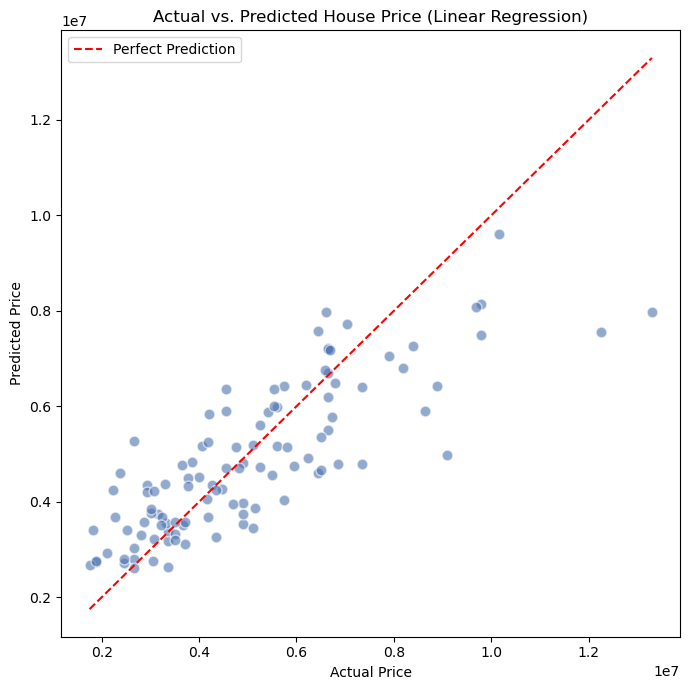

In [34]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, predictions, alpha=0.6, color="#4C72B0", edgecolor="white", s=60)

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect Prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Price (Linear Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("chart3_actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

- **Chart 1 (Histogram):** Prices are right-skewed — most houses cluster in the lower-to-mid price range, with a tail of expensive outliers pulling the mean above the median.
- **Chart 2 (Heatmap):** area and bathrooms show the strongest positive correlation with price; furnishingstatus_unfurnished is the strongest negative correlation, confirming the trend seen in Task 2.
- **Chart 3 (Actual vs. Predicted):** Most points cluster reasonably close to the perfect-prediction line at lower price ranges, with prediction error growing for the most expensive houses — consistent with the R² of ~0.65 found in Task 3 (the model explains about two-thirds of price variation, but isn't fully accurate, especially for outliers).

# Task 5 — Insights & Summary
**Dataset:** Housing_cleaned.csv

## Recap of key numbers (from earlier tasks)

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("Housing_cleaned.csv")
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
predictions = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
mean_price = df["price"].mean()

print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"R2   : {r2:.3f}")
print(f"Average house price: {mean_price:,.0f}")
print(f"MAE as % of average price: {mae / mean_price * 100:.1f}%")
print()
print("Top correlated features with price:")
print(df.corr(numeric_only=True)["price"].drop("price").sort_values(ascending=False).head(5))

MAE  : 970,043
RMSE : 1,324,507
R2   : 0.653
Average house price: 4,766,729
MAE as % of average price: 20.4%

Top correlated features with price:
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
Name: price, dtype: float64


## Insights & Summary

The main factors driving house prices in this dataset are area and number of bathrooms. Next are air conditioning, number of stories, and parking spaces; all of these show a clear positive relationship with price. In contrast, being unfurnished lowers the price. 

In simple terms, the Linear Regression model is moderately precise. It explains about 65% of the variation in price (R² ≈ 0.65). Its average prediction is off by around ₹970,000, which is about 20% of the average house price (~₹4.77M). This is useful for a rough estimate but not accurate enough for setting an exact listing price. 

What stood out in the data is that the simpler Linear Regression model slightly outperformed Random Forest. This suggests that prices in this dataset increase fairly linearly with features like area and bathrooms, instead of depending on complex feature interactions. Additionally, the price distribution is right-skewed, with a few expensive houses raising the average above the typical (median) home. 

For a real estate business, since **area, bathrooms, and air conditioning have the biggest impact on price**, agents and **developers should focus on highlighting and improving these attributes in listings and renovations**. These features provide the best opportunity for justifying a higher asking price. Meanwhile, aspects like hot water heating have little effect on price and are not worth stressing in marketing.